# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [78]:
# Import essential libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist #to load data
from tensorflow.keras.models import Sequential # Modell - NN Architecture
from tensorflow.keras.layers import Dense, Flatten #Layers - NN Architecture
from tensorflow.keras.utils import to_categorical #required only for multi class classification problem



Load the dataset.

In [3]:
# Load and unzip the dataset
!unzip /Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C4/Assignment/data.zip
!ls


Archive:  /Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C4/Assignment/data.zip
  inflating: data/Food_Waste/file_931.png  
  inflating: data/Food_Waste/file_663.png  
  inflating: data/Food_Waste/file_468.png  
  inflating: data/Food_Waste/file_659.png  
  inflating: data/Food_Waste/file_321.png  
  inflating: data/Food_Waste/file_88.png  
  inflating: data/Food_Waste/file_156.png  
  inflating: data/Food_Waste/file_211.png  
  inflating: data/Food_Waste/file_538.png  
  inflating: data/Food_Waste/file_36.png  
  inflating: data/Food_Waste/file_871.png  
  inflating: data/Food_Waste/file_56.png  
  inflating: data/Food_Waste/file_696.png  
  inflating: data/Food_Waste/file_427.png  
  inflating: data/Food_Waste/file_861.png  
  inflating: data/Food_Waste/file_681.png  
  inflating: data/Food_Waste/file_295.png  
  inflating: data/Food_Waste/file_963.png  
  inflating: data/Food_Waste/file_51.png  
  inflating: data/Food_Waste/file_634.png  
  inflating: d

## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [5]:
# Create a function to load the raw images
data_dir = "/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C4/Assignment/data"


In [23]:
def load_dataset(data_dir, img_size=(128,128), batch_size=32,normalize=True):
    main_ds = tf.keras.utils.image_dataset_from_directory(data_dir, image_size=img_size,batch_size=batch_size,shuffle=True)
    class_names = main_ds.class_names
    if normalize:
        rescale = tf.keras.layers.Rescaling(1./255)
        main_ds = main_ds.map(lambda x,y: (rescale(x),y), num_parallel_calls=tf.data.AUTOTUNE)
    
    main_ds = main_ds.prefetch(tf.data.AUTOTUNE)
    
    return main_ds, class_names

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [30]:
# Get the images and their labels
main_ds,class_names = load_dataset(data_dir)
print("Classes:", class_names)


Found 7625 files belonging to 7 classes.
Classes: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


In [31]:
for images, labels in main_ds.take(1):
    print("Image Batch Shape",images.shape)
    print("Label Batch Shape",labels.shape)
    print("Label Values",labels.numpy())

Image Batch Shape (32, 128, 128, 3)
Label Batch Shape (32,)
Label Values [0 4 2 4 6 3 5 5 6 6 3 1 3 6 5 2 6 2 4 5 6 0 0 0 0 3 5 6 5 2 3 6]


2025-09-13 18:06:25.605397: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


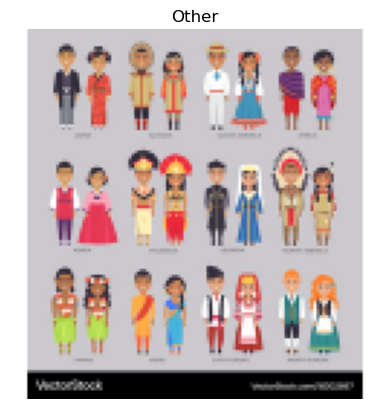

2025-09-13 18:06:26.594894: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
for images, labels in main_ds.take(1):
    sample_img = images[0].numpy()
    sample_label = class_names[labels[0]]
    plt.imshow(sample_img)
    plt.title(sample_label)
    plt.axis("off")
    plt.show()

Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

In [36]:
# Visualise Data Distribution

def plot_class_distribution(dataset, class_names):
    class_counts = np.zeros(len(class_names), dtype=int)

    for _, labels in dataset:
        for label in labels.numpy():
            class_counts[label] += 1
    
    plt.Figure(figsize=(8,6))
    plt.bar(class_names, class_counts)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")
    plt.xticks(rotation=45)
    plt.show()

2025-09-13 18:17:50.970262: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


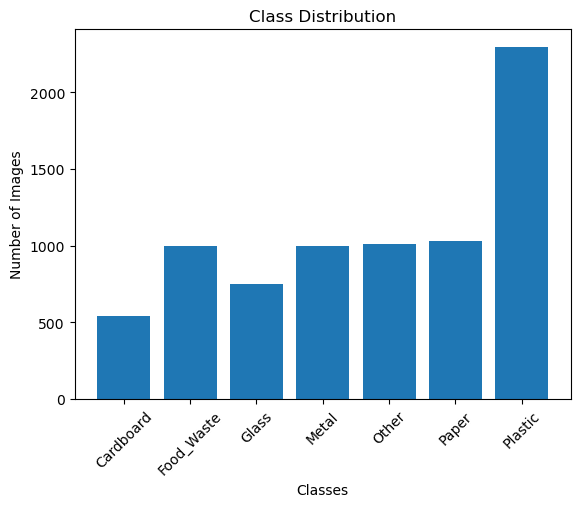

In [37]:
plot_class_distribution(main_ds,class_names)

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

In [39]:
#backing up the main dataset before making changes
main_ds1, class_names1 = load_dataset(data_dir)

Found 7625 files belonging to 7 classes.


In [44]:
def visualize_samples(dataset, class_names, num_classes=7, samples_per_class=5):
    plt.figure(figsize=(samples_per_class*2, num_classes*2))

    #take one batch from dataset
    for images, labels in dataset.take(1):
        for class_idx in range(num_classes):
            #get indexes of images belonging to this class
            idxs = [i for i, label in enumerate(labels.numpy()) if label == class_idx][:samples_per_class]

            for j,idx in enumerate(idxs):
                plt.subplot(num_classes, samples_per_class, class_idx*samples_per_class + j + 1)
                plt.imshow(images[idx].numpy())
                plt.axis("off")
                if j==0:
                    plt.ylabel(class_names[class_idx], fontsize=12)
    
    plt.tight_layout()
    plt.show()

2025-09-13 18:36:44.981405: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


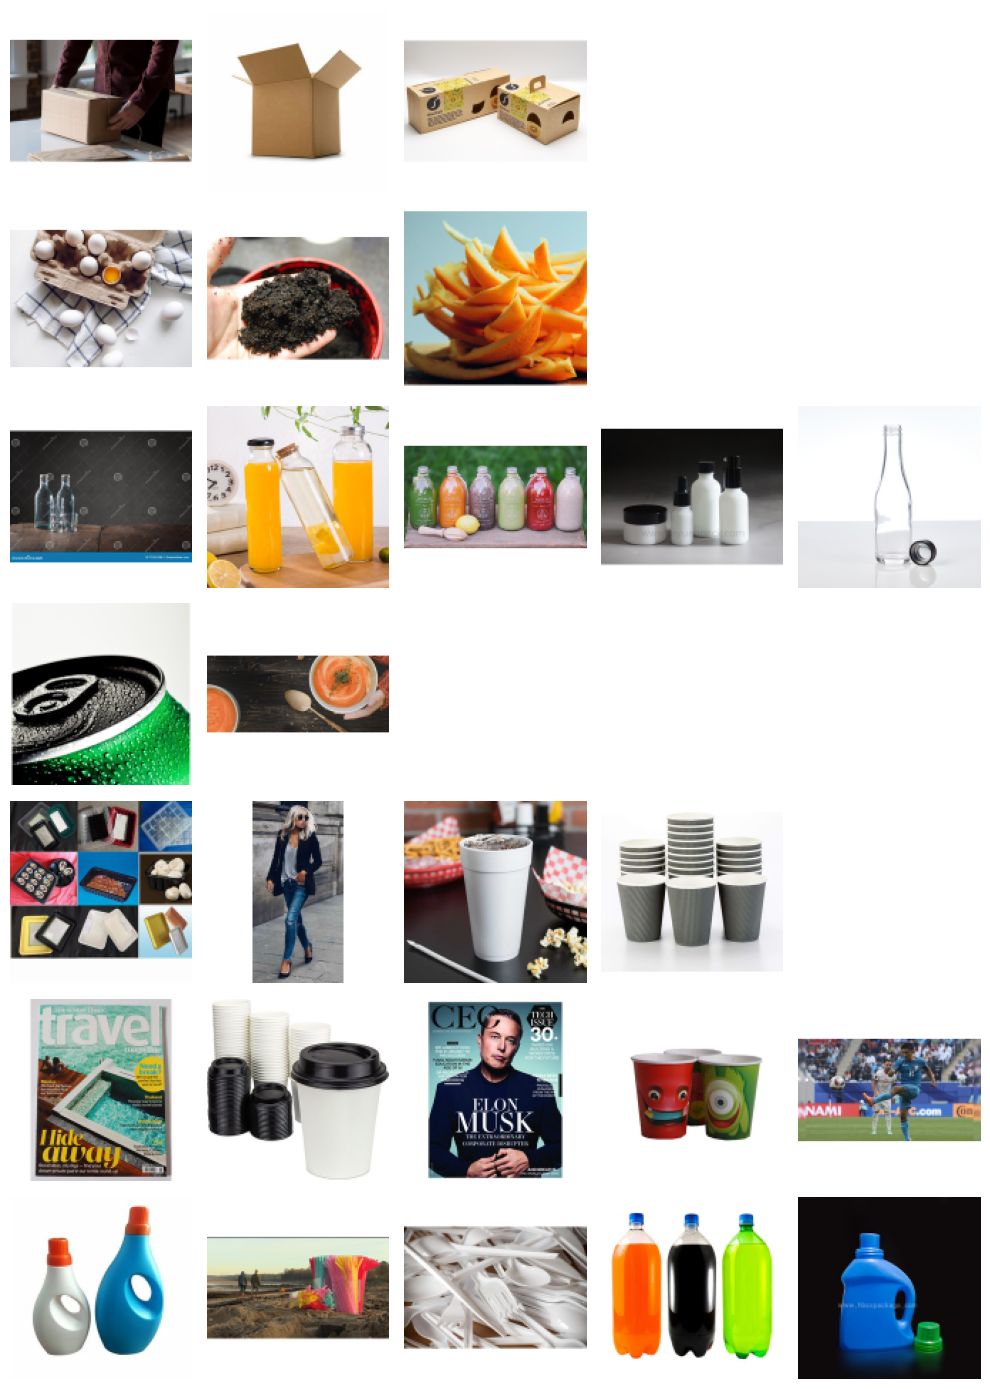

In [45]:
# Visualise Sample Images (across different labels)

visualize_samples(main_ds, class_names, num_classes=len(class_names), samples_per_class=5)


#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [54]:
# Find the smallest and largest image dimensions from the data set
import os
from PIL import Image
def find_image_size(data_dir):
    min_w, min_h = float("inf"),float("inf")
    max_w, max_h = 0,0

    for root,_, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(("png","jpg","jpeg")):
                path = os.path.join(root, file)
                with Image.open(path) as img:
                    w,h = img.size
                    min_w, min_h = min(min_w,w), min(min_h,h)
                    max_w, max_h = max(max_w,w), max(max_h,h)
    return (min_w,min_h), (max_w,max_h)




In [55]:
min_size, max_size = find_image_size(data_dir)
print("Smallest Size:",min_size)
print("Largest Size:",max_size)

Smallest Size: (256, 256)
Largest Size: (256, 256)


In [56]:
# Resize the image dimensions

def resize_image(image, label):
    image = tf.image.resize(image, [256,256])
    return image, label

In [57]:
main_ds1 = main_ds1.map(resize_image)

### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [75]:
# Encode the labels suitably
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(class_names1)
print(y_encoded) 

[0 1 2 3 4 5 6]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [112]:
# Assign specified parts of the dataset to train and validation sets

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

#shuffle before splitting
main_ds1 = main_ds1.shuffle(1000, seed=123)
dataset_size = tf.data.experimental.cardinality(main_ds1).numpy()
train_size = int(0.8*dataset_size)

#split the dataset

train_ds = main_ds1.take(train_size)
val_ds = main_ds1.skip(train_size)

#Normalization based on Accuracy from Model Evaluation
normalization_layer = layers.Rescaling(1./255)
train_ds_normalized = train_ds.map(lambda x,y: (normalization_layer(x),y))
val_ds_normalized = val_ds.map(lambda x,y: (normalization_layer(x),y))
test_ds_normalized = val_ds.map(lambda x,y: (normalization_layer(x),y))

#PREFETCH

AUTOTUNE = tf.data.AUTOTUNE
train_ds_normalized = train_ds_normalized.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_normalized = val_ds_normalized.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_normalized = val_ds_normalized.cache().prefetch(buffer_size=AUTOTUNE)
y = y_encoded.copy() 



## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [113]:
# Build and compile the model

from tensorflow.keras import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

num_classes = 7

model = models.Sequential()

#Conv block1
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

#Conv block2
model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

#Conv block3
model.add(Conv2D(128,(3,3),activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7,activation='softmax'))

model.compile(optimizer=Adam(0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#Key Features of This Model:

# 3 Conv layers → progressively extract features.

# BatchNormalization → after every conv layer, stabilizes training.

# Dropout → after conv blocks (0.25) and after dense layer (0.5) to prevent overfitting.

# GlobalAveragePooling2D → reduces parameters massively, no huge Dense layer.

# Dense Layers → maps features to output classes.

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [114]:
# Training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss',patience=7, restore_best_weights=True) #updated patience from 5 to 7 after model evaluation

checkpoint = ModelCheckpoint(filepath='best_model.keras', monitor = 'val_loss', save_best_only=True,mode="min")

reduce_lr=ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=3, min_lr=1e-6)



In [115]:

history = model.fit(
    train_ds_normalized, validation_data = val_ds_normalized,
    epochs=50, #increased from 20 to 50 after running the evaluation
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.3209 - loss: 1.7694 - val_accuracy: 0.1126 - val_loss: 1.9989 - learning_rate: 0.0010
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.3621 - loss: 1.6489 - val_accuracy: 0.1452 - val_loss: 2.7569 - learning_rate: 0.0010
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.3933 - loss: 1.5880 - val_accuracy: 0.1465 - val_loss: 5.2739 - learning_rate: 0.0010
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.4107 - loss: 1.5654 - val_accuracy: 0.2741 - val_loss: 9.9707 - learning_rate: 0.0010
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.4385 - loss: 1.4980 - val_accuracy: 0.2233 - val_loss: 2.6983 - learning_rate: 2.0000e-04
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.4528 - loss: 1.4728 - val_accuracy: 0.2819 - val_loss: 2.9127 - learning_rate: 2.0000e-04
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.4602 - 

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [116]:
# Evaluate on the test set; display suitable metrics
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")

test_loss, test_acc = best_model.evaluate(val_ds_normalized)
print(f"Test Accuracy:{test_acc:.4f}")
print(f"Test Loss:{test_loss:.4f}")



48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.4473 - loss: 1.4852
Test Accuracy:0.4473
Test Loss:1.4852


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

Report Findings about the Data:

We saw sample images in the dataset which was of Cardboard, Food waste, Glass, Metal, Paper, Platic and Other classes.
Dataset has the image size of 256x256. Reducing the image size to 128x128 didn't give appropriate results from the model, so we had to go back for 256x256 size for model training. 
After data processing, Encoding was applied on the labels. 


Report Model training results:

CNN Model was developed using 3 Convolutional layers. 

We can see in the model summary that: Total Params are 111,559, Trainable PArams are 111,111, Non trainable params as 448.
After training the model for the 1st time, I observed that it will need more patience and more iterations than 20. So, updated model has patience as 7 (previously 5) and epochs as 50 (previously 25).

Model Validation gave the Accuracy of 44% and loss of 1.48 which is not a good model. We will have to further tune the model via transfer learning which is not in scope of this Assignment. 